# Single perturbations across conditions: kinase inhibitors with and without T cells (glioblastoma)

This tutorial applies SHERLOCK to a sci-Plex screen from Shi et al. (2026): patient-derived BT333
glioblastoma cells were treated with one of 11 kinase inhibitors or with DMSO, the drug was washed
out, and the cells were then cultured with tumour antigen-specific cytotoxic T cells (`0.5T`) or
without them (`NoT`). We analyse the 10 µM dose.

Here each cell has a **perturbation** (the drug) and a **condition** (T-cell co-culture). SHERLOCK
learns each drug's shift relative to DMSO-treated cells *of the same condition*, which lets us ask:

1. Which drugs have similar effects?
2. Whose response depends on the T-cell condition? (a per-drug silhouette score in latent space)
3. Which downstream genes does each drug change in each condition, and which do two drugs share?

## 1. Setup

In [1]:
import os

import numpy as np
import pandas as pd
import scanpy as sc
import torch
import matplotlib.pyplot as plt
import seaborn as sns

import sherlock as slk   # pip install azizilab-sherlock

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## 2. Load and prepare the data

`bt333_degs_tcell_10_1000.h5ad` holds raw counts for the drug-treated and DMSO cells. Its genes are
the union of each drug's differentially expressed genes versus DMSO and the 1,000 genes most
changed by T-cell co-culture in DMSO cells (see the manuscript's Methods). The processed file is
available from the first authors on request; it is built from the raw screen by
`notebooks/gbm/drugs_tcell_1_preprocess.ipynb` in the SHERLOCK repository.

To follow along with your own screen, any AnnData with raw counts, a perturbation column and a
condition column works the same way.

Besides the perturbation, SHERLOCK needs to know which `.obs` column holds the condition and which
value is the reference condition. We set both through the configuration and
`slk_prepare_data`.

In [2]:
GBM_PATH = "../../datasets/gbm/bt333_degs_tcell_10_1000.h5ad"
CONCENTRATION = "10"

data = sc.read_h5ad(GBM_PATH)
data = data[~data.obs["drug"].isna()].copy()
data = data[(data.obs["concentration"] == CONCENTRATION) | (data.obs["drug"] == "DMSO")].copy()

slk.configs.reset_config()
slk.configs.set_config({"pert_key": "drug", "ntc_label": "DMSO",
                        "treatment_key": "tcell_treatment", "untreated_label": "NoT"})
slk.pp.slk_prepare_data(data, pert_key="drug", ntc_label="DMSO",
                        treatment_key="tcell_treatment", untreated_label="NoT", inplace=True)

print(f"{data.n_obs:,} cells x {data.n_vars:,} genes")
pd.crosstab(data.obs["drug"], data.obs["tcell_treatment"])

35,511 cells x 2,894 genes


tcell_treatment,0.5T,NoT
drug,,
ALWII4127,964,509
Abemaciclibmesylate,719,614
BAY1217389,478,425
CP673451,851,472
DMSO,9253,8037
Laduviglusib,1680,445
PF06260933,1600,738
SGCAAK11,1315,566
STK16IN1,861,1222


In [3]:
slk.pp.treat_effect(data, label_col="drug", control_label="DMSO", method="perturbseq",
                    inplace=True, key="treat_effect")

## 3. Train SHERLOCK with conditions

`use_conditions=True` makes the baseline latent state condition-specific. The settings are those
used in the manuscript for this screen:

| argument | value | role |
|---|---|---|
| `latent_dim` | 8 | size of the latent cell state |
| `rank` | 3 | rank of the perturbation covariance |
| `l0_lambda`, `n_epochs_l0_warmup` | 200, 200 | gate sparsity and its warm-up |
| `num_epochs`, `patience`, `validate_every` | 1000, 500, 20 | training length and early stopping |

Training takes about 20 minutes on a GPU. A saved checkpoint is loaded when present.

In [4]:
CHECKPOINT = "../../results/tutorials/gbm_drug_10uM.pth"
RETRAIN = False

if not RETRAIN and os.path.exists(CHECKPOINT):
    model = slk.tl.load_results(CHECKPOINT).to(DEVICE)
    print(f"Loaded {CHECKPOINT}")
else:
    out = slk.tl.run(
        data, model="vae", use_conditions=True,
        latent_dim=8, rank=3, l0_lambda=200, n_epochs_l0_warmup=200,
        batch_size=4096, num_epochs=1000, validate_every=20, patience=500,
        seed=2, device=DEVICE,
    )
    slk.tl.save_results(out, CHECKPOINT)
    model = out["model"]

Loaded ../../results/tutorials/gbm_drug_10uM.pth


In [5]:
slk.tl.eval(model, data, obsm_key="z", uns_key="results", device=DEVICE)
res = data.uns["results"]
print("Conditions:", list(res["conditions"]))

Conditions: ['NoT', '0.5T']


## 4. Latent space

In SHERLOCK's latent space, drug-treated cells separate by drug and by T-cell condition.

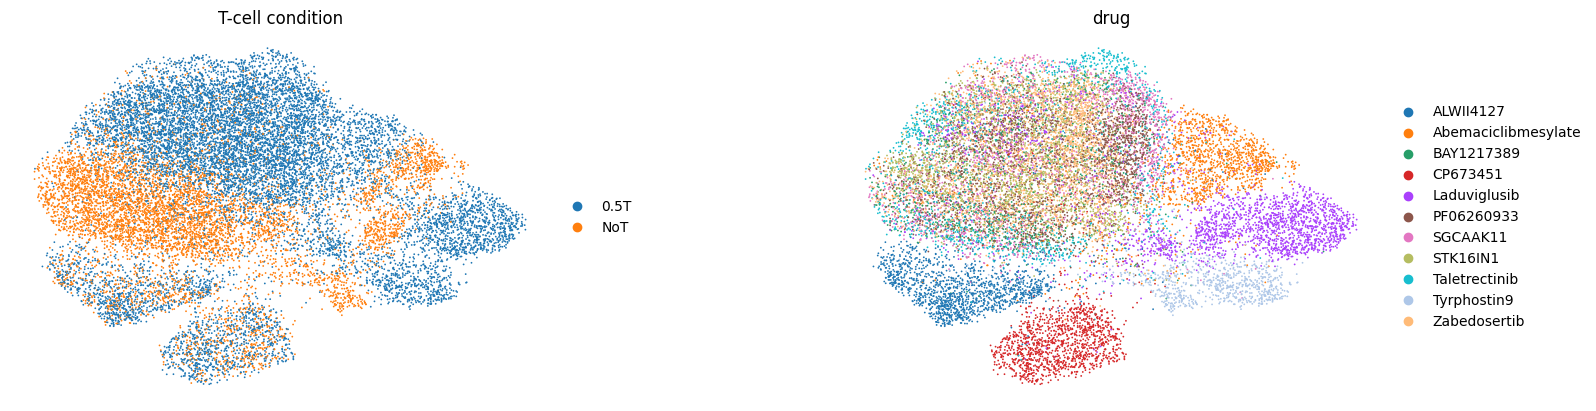

In [6]:
sub = data[data.obs["drug"] != "DMSO"].copy()
sc.pp.neighbors(sub, n_neighbors=15, use_rep="z", random_state=0)
sc.tl.umap(sub, random_state=0)
sc.pl.umap(sub, color=["tcell_treatment", "drug"], palette=None, frameon=False, wspace=0.4,
           title=["T-cell condition", "drug"])

## 5. Which drugs act alike?

`rho_corr` is the correlation between the drugs' learned effects. Hierarchical clustering with a
fixed cut groups the drugs; at 10 µM, CP673451 (a PDGFRA inhibitor) and ALWII4127 (an EPHA2
inhibitor) fall in the same group.

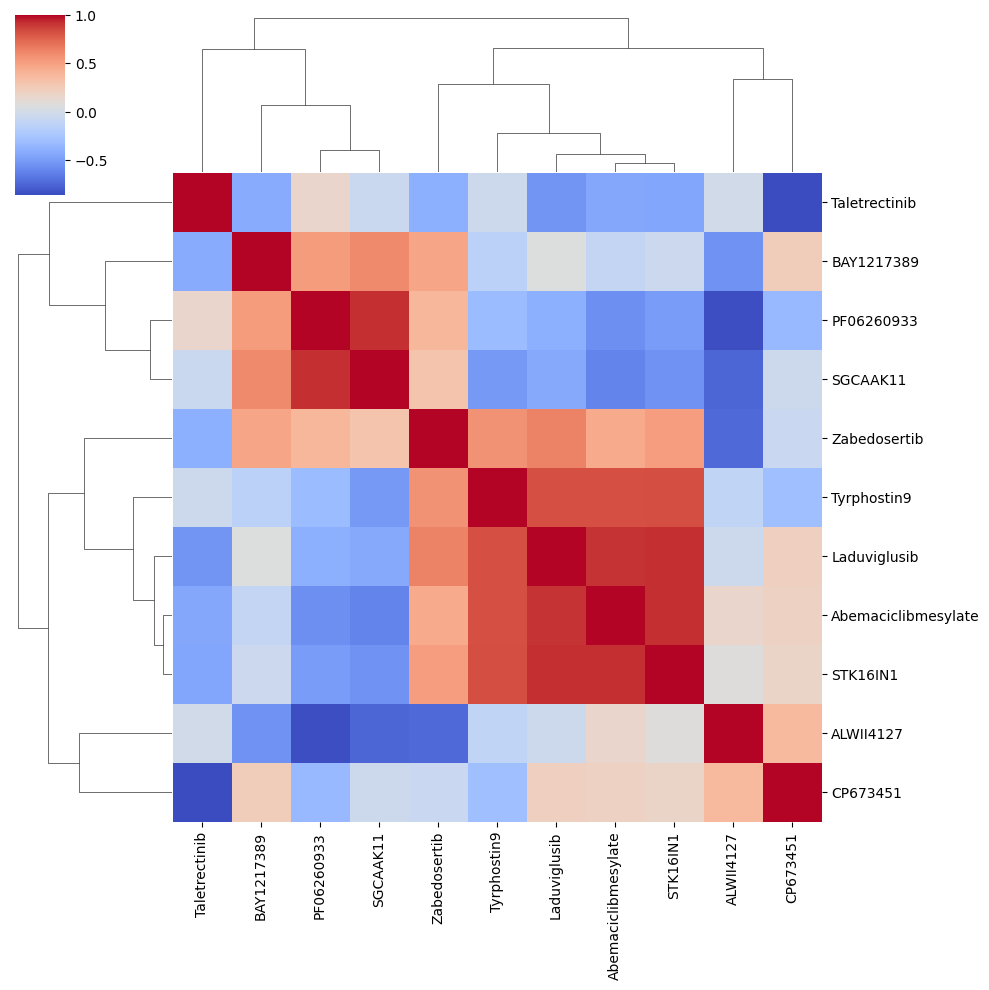

In [7]:
slk.pl.plot_corr(data)
plt.show()

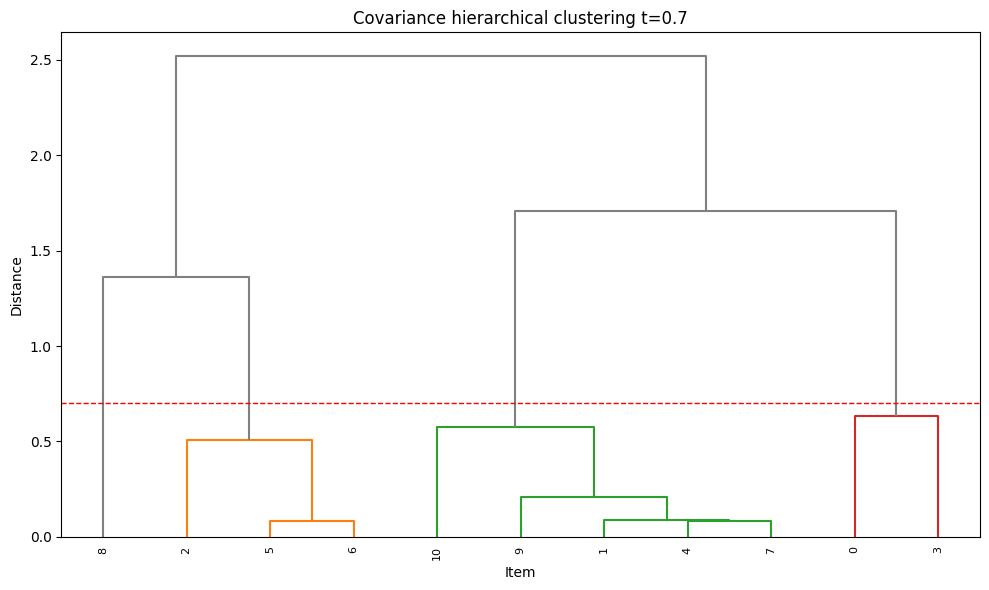

,group
BAY1217389,1
PF06260933,1
SGCAAK11,1
Taletrectinib,2
Laduviglusib,3
STK16IN1,3
Tyrphostin9,3
Abemaciclibmesylate,3
Zabedosertib,3
CP673451,4


In [8]:
CLUSTER_T = 0.7
groups = slk.tl.cluster_rho(data, t=CLUSTER_T, show=True)
drug_groups = slk.tl.group2name(groups, list(res["rho_perts"]))
drug_groups.sort_values("group")

## 6. Whose response depends on the T-cell condition?

For each drug, `condition_perturbation_interaction` takes only that drug's cells, labels them by
condition and computes the mean silhouette in latent space. A high score means the drug's cells
separate by condition, so its effect is reshaped by T cells; a score near zero means the drug acts
the same way in both conditions.

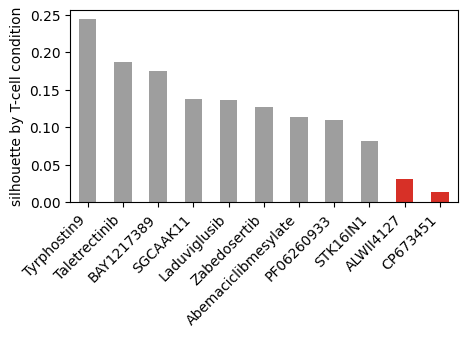

In [9]:
cpi = res["condition_perturbation_interaction"]           # (drugs, conditions, conditions)
pairs = np.triu(np.ones(cpi.shape[1:], dtype=bool), k=1)
score = pd.Series([np.nanmean(cpi[p][pairs]) for p in range(cpi.shape[0])],
                  index=list(res["rho_perts"]), name="conditional response").sort_values(ascending=False)

ax = score.plot.bar(figsize=(5, 2.5), color=["#d73027" if d in ("CP673451", "ALWII4127") else "#9e9e9e"
                                             for d in score.index])
ax.set(ylabel="silhouette by T-cell condition", xlabel="")
plt.xticks(rotation=45, ha="right")
plt.show()

## 7. Downstream genes in each condition

`counterfactual_effect_size` gives, for each drug and condition, how strongly applying the drug to
condition-matched DMSO backgrounds changes each gene once decoded. `slk.tl.ev_sig` tests which genes
are affected unusually strongly for each drug, separately per condition.

In [10]:
cond_names = list(res["conditions"])
for c in range(len(cond_names)):
    slk.tl.ev_sig(data, cond_idx=c)

shared = {}
for c, name in enumerate(cond_names):
    ev = slk.pl.make_ev_long_df(data, cond_idx=c)
    sig = ev[ev["qval"] < 0.05]
    cp, al = (set(sig.loc[sig["pert"] == d, "gene"]) for d in ("CP673451", "ALWII4127"))
    shared[name] = sorted(cp & al)
    print(f"{name}: CP673451 {len(cp)} genes, ALWII4127 {len(al)} genes, shared {len(cp & al)}")

NoT: CP673451 652 genes, ALWII4127 588 genes, shared 288
0.5T: CP673451 637 genes, ALWII4127 659 genes, shared 401


With T cells present, the two drugs share more significant downstream genes (counts above). The
bipartite graphs show each drug's 15 strongest downstream genes in each condition.

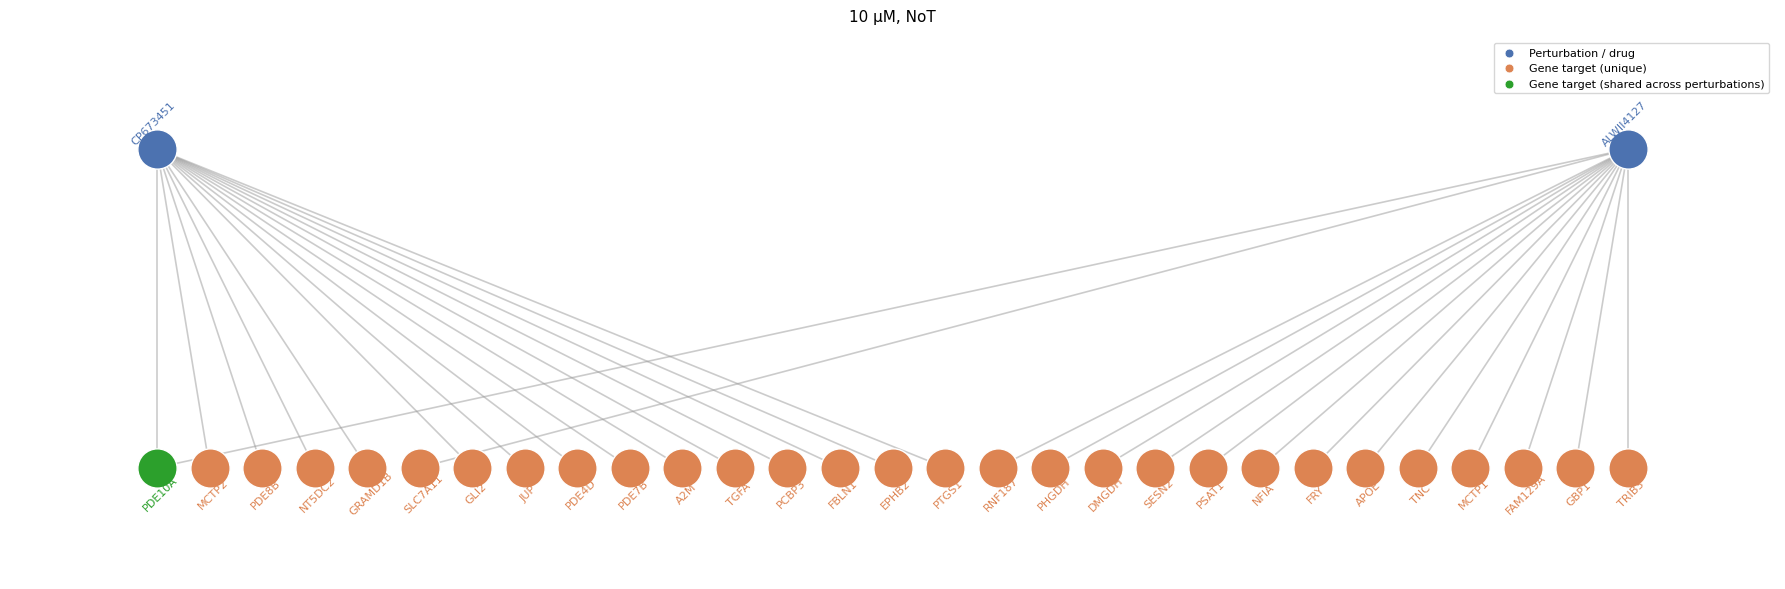

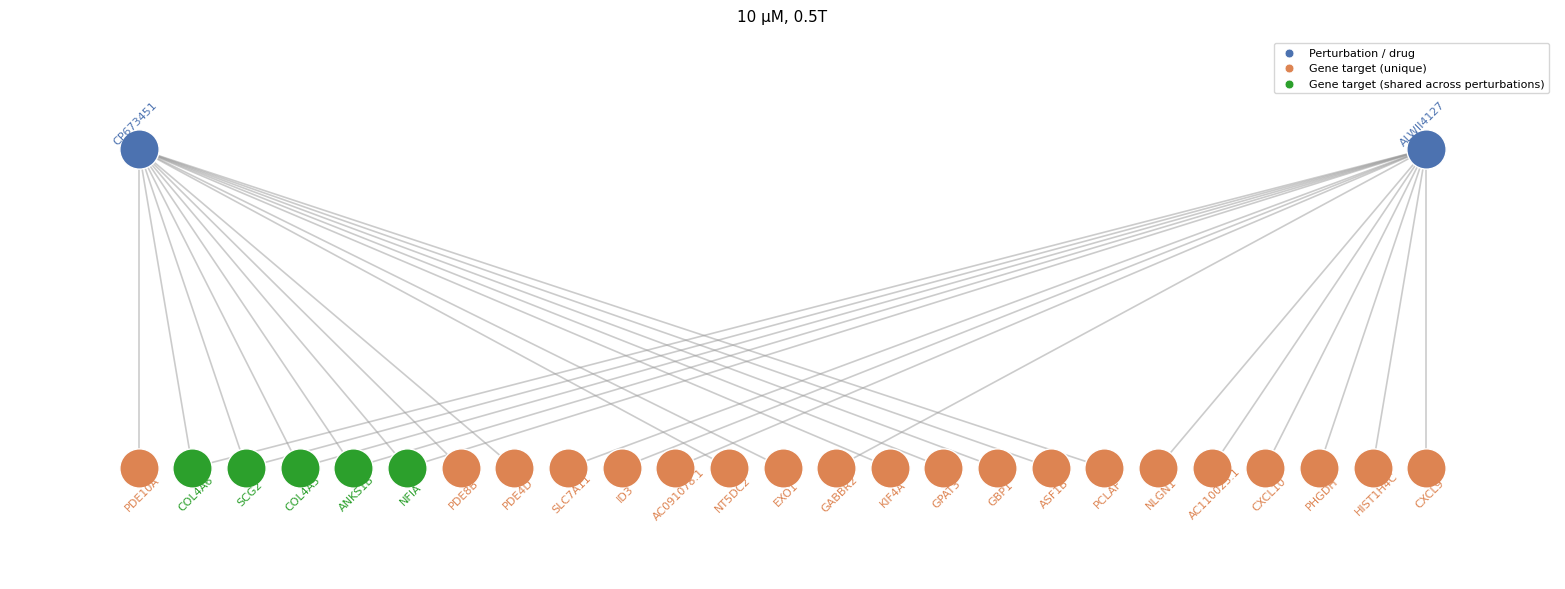

In [11]:
for c, name in enumerate(cond_names):
    slk.pl.plot_cf_bipartite(data, cond_idx=c, pert_name=["CP673451", "ALWII4127"], top_n=15,
                             title=f"10 µM, {name}")
    plt.show()

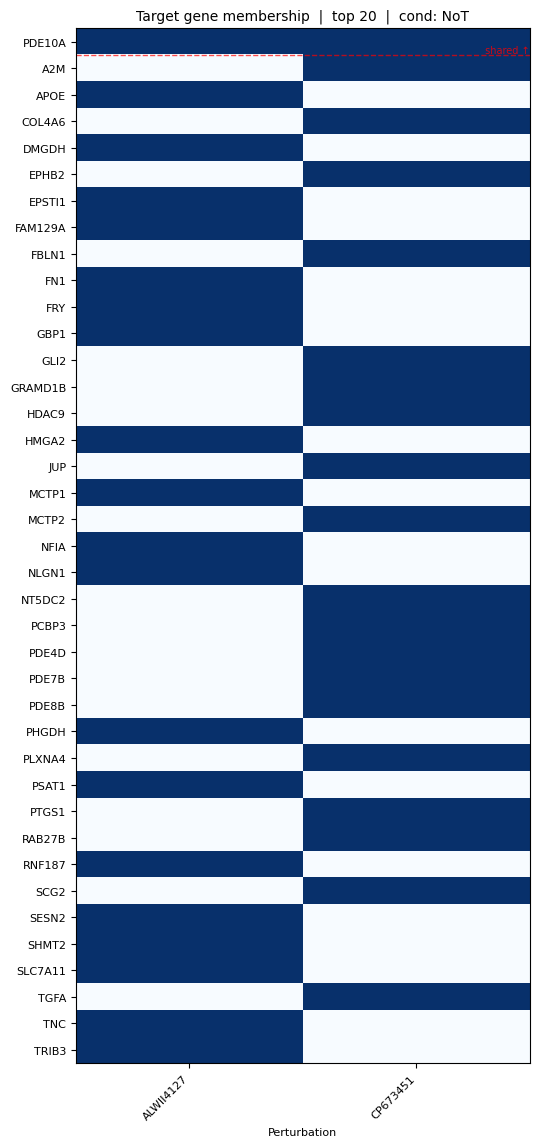

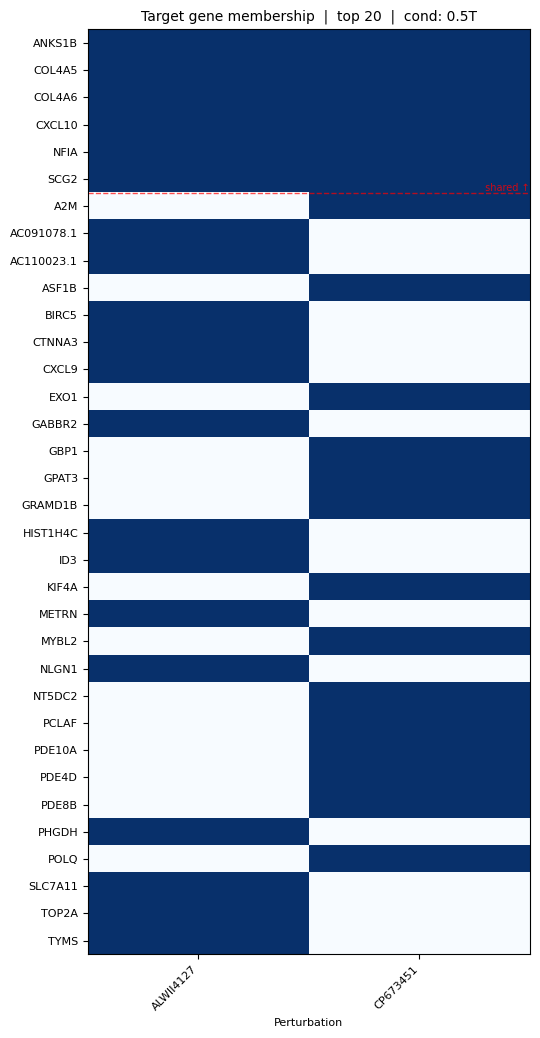

In [12]:
for c, name in enumerate(cond_names):
    slk.pl.plot_cf_target_overlap(data, cond_idx=c, top_n=20, pert_names=["CP673451", "ALWII4127"],
                                  show_jaccard=False, show_membership=True)
    plt.show()

## Next steps

- The manuscript repeats this analysis at 1 µM, compares the two doses, and checks the shared genes
  in the measured expression. That code is in
  [SHERLOCK_Reproducibility](https://github.com/azizilab/SHERLOCK_Reproducibility).
- To analyse your own screen with conditions, set `treatment_key` and `untreated_label` to your
  condition column and reference value, and train with `use_conditions=True`.
- Without conditions, see the [single-perturbation tutorial](single_perturbations.ipynb); for combinations of perturbations, see
  the [combinatorial-perturbation tutorial](combinatorial_perturbations.ipynb).

## References

1. Zhang M, Myers JD, Shi L, Giglio RM, Chatterjee S, McFaline-Figueroa JL, Azizi E. SHERLOCK: Structured representation learning and causal inference of downstream perturbation effects. *bioRxiv* (2026). [doi:10.64898/2026.09.25.754573](https://www.biorxiv.org/content/10.64898/2026.09.25.754573v1)
2. Shi L *et al.* Mapping kinase-dependent tumor immune adaptation with multiplexed single-cell CRISPR screens. *bioRxiv* (2026). [doi:10.64898/2026.01.08.698516](https://doi.org/10.64898/2026.01.08.698516)
3. Srivatsan SR *et al.* Massively multiplex chemical transcriptomics at single-cell resolution. *Science* **367**, 45–51 (2020). [doi:10.1126/science.aax6234](https://doi.org/10.1126/science.aax6234)